In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn as sk
import pandas as pd

# Categorical data
using numbers for each value is bad because it implies relationships based on the values picked for each category. Use hot-encoding to represent cateogrical data with a column per category, holding a binary value (0 or 1) to indicate the presence of that category. This avoids any unintended ordinal relationships between categories.

In [2]:
from sklearn.feature_extraction import DictVectorizer

taxis = sns.load_dataset('taxis')
taxis = taxis.dropna(subset=['pickup_borough', 'dropoff_borough'])
taxis = taxis[['pickup_borough', 'fare']]
vec = DictVectorizer(sparse=False)
feature_arr = vec.fit_transform(taxis.to_dict(orient='records'))
print(feature_arr[:5])
print(vec.get_feature_names_out())

[[ 7.   0.   0.   1.   0. ]
 [ 5.   0.   0.   1.   0. ]
 [ 7.5  0.   0.   1.   0. ]
 [27.   0.   0.   1.   0. ]
 [ 9.   0.   0.   1.   0. ]]
['fare' 'pickup_borough=Bronx' 'pickup_borough=Brooklyn'
 'pickup_borough=Manhattan' 'pickup_borough=Queens']


# text features
encodes text as numbers in most cases. word counts is common

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.datasets import fetch_20newsgroups
data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(data.data)

feature_names = vec.get_feature_names_out()
word_counts = np.asarray(X.sum(axis=0)).ravel()
top_idx = word_counts.argsort()[-20:][::-1]
top_features = feature_names[top_idx]

print('matrix shape:', X.shape)
print('top feature names:', top_features)

display_df = pd.DataFrame(X[:5, top_idx].toarray(), columns=top_features)
display(display_df)

matrix shape: (11314, 101322)
top feature names: ['ax' 'max' 'people' 'like' 'don' 'just' 'know' 'use' 'think' 'time'
 'does' 'new' 'good' 'edu' 'way' 'make' 'god' 'used' 've' 'say']


,ax,max,people,like,don,just,know,use,think,time,does,new,good,edu,way,make,god,used,ve,say
0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,1,2,2,1,1,0,1,2,1,1,1,1,1,0,0,1,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0


# image features
encode to numerical values. can use color histograms, or pixel values. can also use pretrained models to extract features from images.

# derived features
features made by computations on other features. Like polynomial coefficients for regressions.

[[1.00000000e+00 7.38164436e-01 5.44886735e-01 4.02216009e-01
  2.96901554e-01 2.19162168e-01 1.61777718e-01]
 [1.00000000e+00 2.83878661e+00 8.05870941e+00 2.28769564e+01
  6.49427974e+01 1.84358744e+02 5.23355133e+02]
 [1.00000000e+00 4.78063578e+00 2.28544785e+01 1.09258938e+02
  5.22327187e+02 2.49705604e+03 1.19375155e+04]
 [1.00000000e+00 7.99299133e+00 6.38879103e+01 5.10655513e+02
  4.08166509e+03 3.26247136e+04 2.60769053e+05]
 [1.00000000e+00 8.33873568e+00 6.95345127e+01 5.79829922e+02
  4.83504846e+03 4.03181911e+04 3.36202739e+05]]


<Axes: >

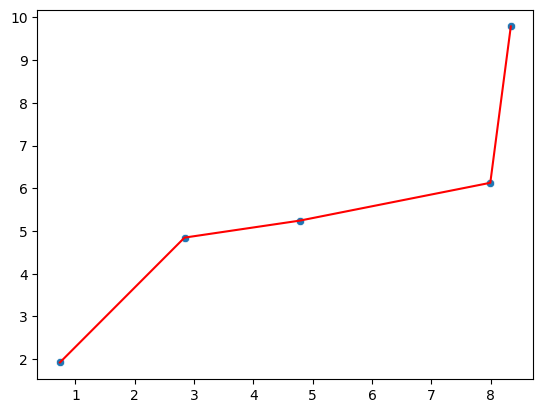

In [20]:
x = np.sort(np.random.uniform(0, 10, size=5))
y = np.sort(np.random.uniform(0, 10, size=5))
sns.scatterplot(x=x, y=y)
X = x.reshape(-1, 1)
poly = sk.preprocessing.PolynomialFeatures(degree=6)
X_poly = poly.fit_transform(X)
print(X_poly)
model = sk.linear_model.LinearRegression().fit(X_poly, y)
fitted_y = model.predict(X_poly)
sns.lineplot(x=x, y=fitted_y, color='red')

# imputation of missing data

In [31]:
arr = np.random.randint(0, 10, size=(5, 5)).astype(float)
indices_to_nan = np.random.choice(arr.size, size=5, replace=False)
arr.ravel()[indices_to_nan] = np.nan

from sklearn.impute import SimpleImputer
print(arr)
print("Median of each column:", np.nanmedian(arr, axis=0))
clean_arr = SimpleImputer(strategy='median').fit_transform(arr)
print(clean_arr)

[[ 4.  1.  6.  9.  9.]
 [nan nan  6.  2.  6.]
 [ 7. nan nan  0.  9.]
 [ 1.  1.  3.  4.  1.]
 [ 8.  8.  9. nan  4.]]
Median of each column: [5.5 1.  6.  3.  6. ]
[[4.  1.  6.  9.  9. ]
 [5.5 1.  6.  2.  6. ]
 [7.  1.  6.  0.  9. ]
 [1.  1.  3.  4.  1. ]
 [8.  8.  9.  3.  4. ]]


# feature pipelines

In [37]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

x = np.random.randint(0, 10, size=(5, 5)).astype(float)
indices_to_nan = np.random.choice(x.size, size=5, replace=False)
x.ravel()[indices_to_nan] = np.nan
y = np.random.randint(0, 10, size=5)

model = make_pipeline(SimpleImputer(strategy='median'), PolynomialFeatures(degree=9), LinearRegression())

model.fit(x, y)
predictions = model.predict(x)
print("Predictions:", predictions)
print("y:", y)

Predictions: [5. 5. 3. 3. 2.]
y: [5 5 3 3 2]
